In [25]:
from pathlib import Path
import os
print("Current working directory:", Path.cwd())
print("Contents of cwd:", os.listdir())

Current working directory: /home/cysoft/GlorifyProj
Contents of cwd: ['.ipynb_checkpoints', 'GlorifyProj_notebook.ipynb', 'venv', 'scripts', 'models', 'Pipfile', 'data', 'Readme.md', 'outputs', 'requirements.txt', 'Pipfile.lock']


# Modeling Crystal Violet Dye Removal Using Machine Learning
### ANN, Random Forest, and SVR — Data Generation, Training, Evaluation & Interpretation

This notebook runs the full pipeline end-to-end in one place:

1. Generate/load data
2. Preprocess (70/30 split + scaling)
3. Train & tune Random Forest and SVR (baseline models)
4. Train & tune ANN
5. Evaluate all 3 models on the held-out test set (R², RMSE, MAE, MAPE)
6. Interpret the best model (feature importance + SHAP)

Run cells top to bottom. If you already have a real dataset, see the
note in **Section 1** — you can skip synthetic generation entirely.


## Setup
Install/import everything needed. Run this cell first.

In [26]:
# If shap isn't installed yet, uncomment the line below and run once:
# %pip install shap --quiet

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error,
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Project folders (created relative to this notebook's location)
ROOT = Path.cwd()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"
OUTPUTS_DIR = ROOT / "outputs"

for d in (RAW_DIR, PROCESSED_DIR, MODELS_DIR, OUTPUTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

RAW_PATH = RAW_DIR / "cv_removal_data.csv"

FEATURE_COLS = [
    "Initial_Concentration_mgL",
    "Adsorbent_Dosage_gL",
    "pH",
    "Contact_Time_min",
    "Temperature_C",
]
TARGET_COL = "Removal_Efficiency_percent"

FEATURE_LABELS = {
    "Initial_Concentration_mgL": "Initial Concentration (mg/L)",
    "Adsorbent_Dosage_gL": "Adsorbent Dosage (g/L)",
    "pH": "pH",
    "Contact_Time_min": "Contact Time (min)",
    "Temperature_C": "Temperature (C)",
}

print("Project root:", ROOT)


Project root: /home/cysoft/GlorifyProj


## Section 1 — Data

**If you already have the real 270-point experimental CSV:** save it as
`data/raw/cv_removal_data.csv` with the column names above, then
**skip the next cell** and jump straight to *Section 2 — Preprocessing*.

**Otherwise**, the cell below generates a synthetic placeholder dataset
that mimics the thesis's OFAT (one-factor-at-a-time) design: 270 rows,
5 input variables swept individually around a baseline condition, with
R% generated from a plausible non-linear surrogate (kinetics × dose
saturation × concentration overload × pH optimum × temperature effect,
plus noise). This is **not real experimental data** — replace it as
soon as you have the real dataset.

In [22]:
# OFAT factor levels (from thesis section 3.1.1)
C0_LEVELS = [10, 20, 40, 60, 80, 100]           # mg/L
DOSE_LEVELS = [0.2, 0.4, 0.6, 0.8, 1.0]         # g/L
PH_LEVELS = [2, 4, 6, 8, 10, 12]
TIME_LEVELS = [5, 10, 20, 30, 45, 60, 90, 120]  # min
TEMP_LEVELS = [25, 35, 45]                      # C

BASE_C0, BASE_DOSE, BASE_PH, BASE_TIME, BASE_TEMP = 40, 0.6, 6, 60, 35
N_TARGET = 270

def build_ofat_grid():
    rows = [dict(C0=BASE_C0, dose=BASE_DOSE, pH=BASE_PH, time=BASE_TIME, temp=BASE_TEMP)]
    base_row = rows[0]
    def sweep(varname, levels):
        for lvl in levels:
            row = dict(base_row); row[varname] = lvl
            if row not in rows:
                rows.append(row)
    sweep("C0", C0_LEVELS); sweep("dose", DOSE_LEVELS); sweep("pH", PH_LEVELS)
    sweep("time", TIME_LEVELS); sweep("temp", TEMP_LEVELS)
    return pd.DataFrame(rows).drop_duplicates().reset_index(drop=True)

def simulate_removal(df, rng):
    C0, dose = df["C0"].values.astype(float), df["dose"].values.astype(float)
    pH, t, T = df["pH"].values.astype(float), df["time"].values.astype(float), df["temp"].values.astype(float)

    time_term = (0.06 * t) / (1 + 0.06 * t)
    dose_term = dose / (dose + 0.35)
    conc_term = 1.0 / (1.0 + (C0 / 55.0) ** 1.1)
    ph_term = np.exp(-((pH - 7.0) ** 2) / (2 * 3.2 ** 2))
    temp_term = 0.85 + 0.15 * (T - 25) / 20.0

    base = 100 * (0.30*time_term + 0.25*dose_term + 0.20*conc_term + 0.15*ph_term + 0.10*temp_term)
    interaction = 3.0 * (dose_term * time_term) - 2.0 * (conc_term * (1 - ph_term))
    r = base + interaction
    r += rng.normal(0.0, 1.8, size=(len(df), 3)).mean(axis=1)
    return np.round(np.clip(r, 0, 100), 2)

def pad_to_target(df, target_n, rng):
    if len(df) >= target_n:
        return df.iloc[:target_n].reset_index(drop=True)
    extra_idx = rng.choice(len(df), size=target_n - len(df), replace=True)
    return pd.concat([df, df.iloc[extra_idx].reset_index(drop=True)], ignore_index=True)

rng = np.random.default_rng(RANDOM_SEED)
grid = build_ofat_grid()
grid = pad_to_target(grid, N_TARGET, rng)
grid["R_percent"] = simulate_removal(grid, rng)

grid = grid.rename(columns={
    "C0": "Initial_Concentration_mgL", "dose": "Adsorbent_Dosage_gL",
    "pH": "pH", "time": "Contact_Time_min", "temp": "Temperature_C",
    "R_percent": "Removal_Efficiency_percent",
})

grid.to_csv(RAW_PATH, index=False)
print(f"Synthetic dataset written: {RAW_PATH}  shape={grid.shape}")
grid.head()


Synthetic dataset written: /home/cysoft/GlorifyProj/data/raw/cv_removal_data.csv  shape=(270, 6)


,Initial_Concentration_mgL,Adsorbent_Dosage_gL,pH,Contact_Time_min,Temperature_C,Removal_Efficiency_percent
0,40,0.6,6,60,35,77.02
1,10,0.6,6,60,35,83.14
2,20,0.6,6,60,35,77.61
3,60,0.6,6,60,35,73.08
4,80,0.6,6,60,35,70.59


## Section 2 — Preprocessing

70/30 train/test split with a fixed seed, then `StandardScaler` fitted
**only on the training set** (no data leakage) and applied to both.

In [27]:
df = pd.read_csv(RAW_PATH)
assert set(FEATURE_COLS + [TARGET_COL]).issubset(df.columns), "Missing expected columns"

X, y = df[FEATURE_COLS], df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURE_COLS, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=FEATURE_COLS, index=X_test.index)

X_train_scaled.to_csv(PROCESSED_DIR / "X_train.csv", index=False)
X_test_scaled.to_csv(PROCESSED_DIR / "X_test.csv", index=False)
y_train.to_csv(PROCESSED_DIR / "y_train.csv", index=False)
y_test.to_csv(PROCESSED_DIR / "y_test.csv", index=False)
joblib.dump(scaler, MODELS_DIR / "scaler.joblib")

print(f"Train: {X_train_scaled.shape[0]} rows (70%)  |  Test: {X_test_scaled.shape[0]} rows (30%)")
X_train_scaled.head()


Train: 189 rows (70%)  |  Test: 81 rows (30%)


,Initial_Concentration_mgL,Adsorbent_Dosage_gL,pH,Contact_Time_min,Temperature_C
84,-0.092478,0.016914,0.011724,0.359248,-3.933869
251,-0.092478,0.016914,2.227523,0.359248,-0.101388
92,-2.475883,0.016914,0.011724,0.359248,-0.101388
201,1.496459,0.016914,0.011724,0.359248,-0.101388
126,-0.092478,0.016914,0.011724,-0.295715,-0.101388


## Section 3 — Baseline Models: Random Forest & SVR

Both tuned via **5-fold cross-validation grid search** on the training
set only (test set stays untouched until Section 5).

> Random Forest's grid search can take a few minutes depending on your
> machine. Shrink `param_grid` below if you want faster iteration.

In [28]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# --- Random Forest ---
rf_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}
rf = RandomForestRegressor(random_state=RANDOM_SEED)
rf_search = GridSearchCV(rf, rf_param_grid, cv=cv, scoring="r2", n_jobs=-1)

t0 = time.time()
rf_search.fit(X_train_scaled, y_train)
print(f"[RF] best params: {rf_search.best_params_}")
print(f"[RF] best CV R2:  {rf_search.best_score_:.4f}  ({time.time()-t0:.1f}s)")

rf_model = rf_search.best_estimator_
joblib.dump(rf_model, MODELS_DIR / "random_forest.joblib")


[RF] best params: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
[RF] best CV R2:  0.9650  (200.4s)


['/home/cysoft/GlorifyProj/models/random_forest.joblib']

In [29]:
# --- SVR ---
svr_param_grid = {
    "C": [0.1, 1, 10, 100, 1000],
    "gamma": [0.001, 0.01, 0.1, 1, "scale"],
    "epsilon": [0.01, 0.1, 0.5],
}
svr = SVR(kernel="rbf")
svr_search = GridSearchCV(svr, svr_param_grid, cv=cv, scoring="r2", n_jobs=-1)

t0 = time.time()
svr_search.fit(X_train_scaled, y_train)
print(f"[SVR] best params: {svr_search.best_params_}")
print(f"[SVR] best CV R2:  {svr_search.best_score_:.4f}  ({time.time()-t0:.1f}s)")

svr_model = svr_search.best_estimator_
joblib.dump(svr_model, MODELS_DIR / "svr.joblib")

pd.DataFrame([
    {"model": "RandomForest", "best_params": rf_search.best_params_, "cv_r2": rf_search.best_score_},
    {"model": "SVR", "best_params": svr_search.best_params_, "cv_r2": svr_search.best_score_},
]).to_csv(OUTPUTS_DIR / "baseline_tuning_summary.csv", index=False)


[SVR] best params: {'C': 1000, 'epsilon': 0.5, 'gamma': 'scale'}
[SVR] best CV R2:  0.9641  (2.1s)


## Section 4 — ANN (Multilayer Perceptron)

2 hidden layers, ReLU activation, Adam optimizer. Neurons-per-layer and
L2 regularization (`alpha`) tuned via 5-fold CV grid search.

In [30]:
ann_param_grid = {
    "hidden_layer_sizes": [(10, 10), (20, 10), (20, 20), (50, 20), (50, 50), (100, 50)],
    "alpha": [0.0001, 0.001, 0.01, 0.1],
}
ann = MLPRegressor(
    activation="relu", solver="adam", max_iter=5000,
    early_stopping=True, n_iter_no_change=25, random_state=RANDOM_SEED,
)
ann_search = GridSearchCV(ann, ann_param_grid, cv=cv, scoring="r2", n_jobs=-1)

t0 = time.time()
ann_search.fit(X_train_scaled, y_train)
print(f"[ANN] best params: {ann_search.best_params_}")
print(f"[ANN] best CV R2:  {ann_search.best_score_:.4f}  ({time.time()-t0:.1f}s)")

ann_model = ann_search.best_estimator_
joblib.dump(ann_model, MODELS_DIR / "ann.joblib")

pd.DataFrame([{"model": "ANN", "best_params": ann_search.best_params_, "cv_r2": ann_search.best_score_}]
             ).to_csv(OUTPUTS_DIR / "ann_tuning_summary.csv", index=False)


[ANN] best params: {'alpha': 0.001, 'hidden_layer_sizes': (20, 20)}
[ANN] best CV R2:  0.9256  (143.0s)


## Section 5 — Test-Set Evaluation

Evaluates all 3 models on the held-out 30% test set using **R², RMSE,
MAE, and MAPE**, and plots predicted vs. actual removal efficiency.

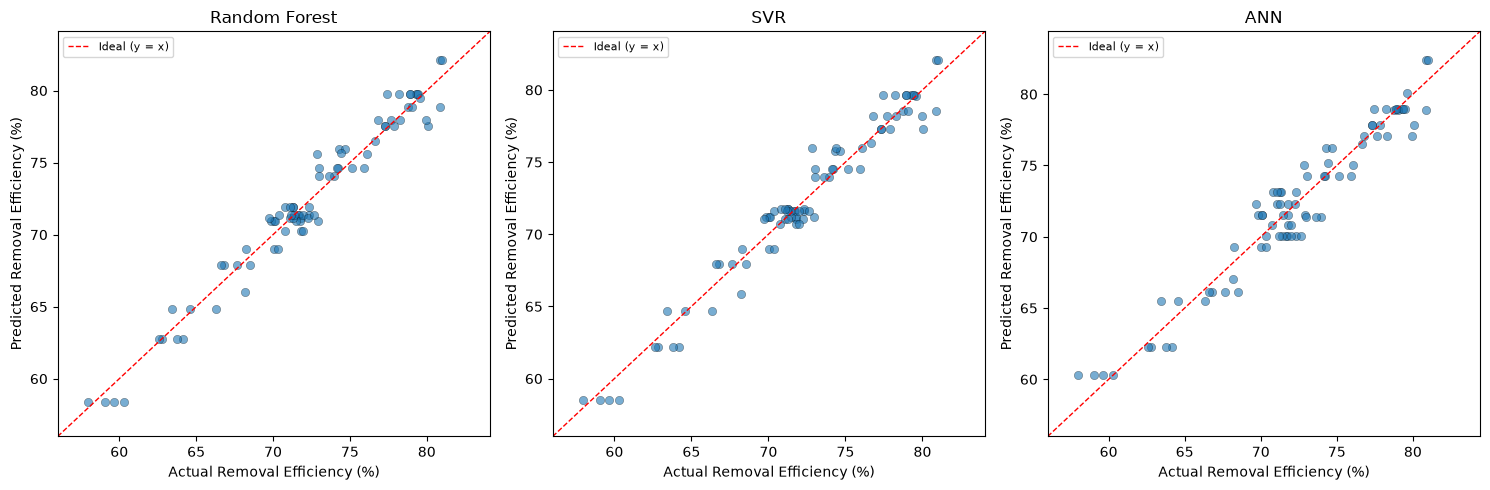


=== Test Set Performance (sorted by R2) ===


,model,R2,RMSE,MAE,MAPE (%)
0,Random Forest,0.959265,1.096774,0.892573,1.242452
1,SVR,0.957914,1.114803,0.882507,1.232426
2,ANN,0.935218,1.383109,1.144600,1.601080



Best model: Random Forest


In [31]:
models = {"Random Forest": rf_model, "SVR": svr_model, "ANN": ann_model}
results = []

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    metrics = {
        "model": name,
        "R2": r2_score(y_test, y_pred),
        "RMSE": rmse,
        "MAE": mean_absolute_error(y_test, y_pred),
        "MAPE (%)": mean_absolute_percentage_error(y_test, y_pred) * 100,
    }
    results.append(metrics)

    ax.scatter(y_test, y_pred, alpha=0.6, edgecolor="k", linewidth=0.3)
    lims = [min(y_test.min(), y_pred.min()) - 2, max(y_test.max(), y_pred.max()) + 2]
    ax.plot(lims, lims, "r--", linewidth=1, label="Ideal (y = x)")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Actual Removal Efficiency (%)")
    ax.set_ylabel("Predicted Removal Efficiency (%)")
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "predicted_vs_actual.png", dpi=150)
plt.show()

results_df = pd.DataFrame(results)[["model", "R2", "RMSE", "MAE", "MAPE (%)"]].sort_values(
    "R2", ascending=False).reset_index(drop=True)
results_df.to_csv(OUTPUTS_DIR / "test_set_metrics.csv", index=False)

print("\n=== Test Set Performance (sorted by R2) ===")
display(results_df)
print(f"\nBest model: {results_df.iloc[0]['model']}")


## Section 6 — Interpretation: Feature Importance + SHAP

Runs on the **best-performing model** from Section 5 (feature
importance requires a tree-based model; SHAP `TreeExplainer` likewise
applies to Random Forest here).

Best-performing model: Random Forest


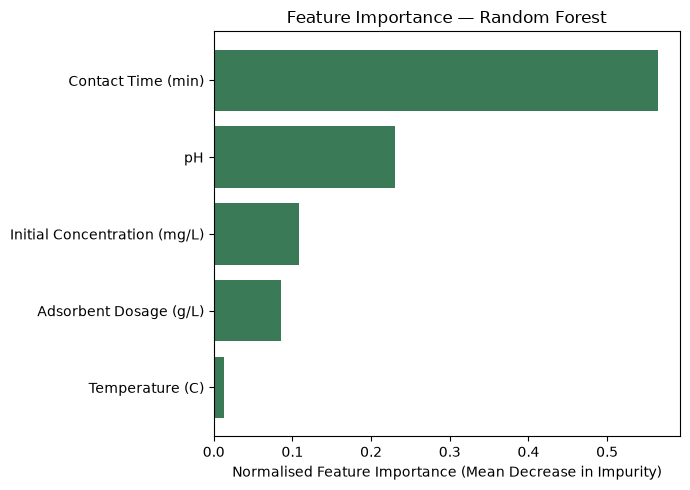

,feature,importance
0,Contact Time (min),0.564408
1,pH,0.230180
2,Initial Concentration (mg/L),0.107909
3,Adsorbent Dosage (g/L),0.084917
4,Temperature (C),0.012585


In [32]:
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]
print(f"Best-performing model: {best_model_name}")

if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    importances = importances / importances.sum()
    fi_df = pd.DataFrame({
        "feature": [FEATURE_LABELS.get(f, f) for f in FEATURE_COLS],
        "importance": importances,
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    fi_df.to_csv(OUTPUTS_DIR / "feature_importance.csv", index=False)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(fi_df["feature"][::-1], fi_df["importance"][::-1], color="#3B7A57")
    ax.set_xlabel("Normalised Feature Importance (Mean Decrease in Impurity)")
    ax.set_title(f"Feature Importance — {best_model_name}")
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / "feature_importance.png", dpi=150)
    plt.show()

    display(fi_df)
else:
    print(f"{best_model_name} has no native feature_importances_ — skipping MDI step. "
          f"(Only Random Forest does in this study.)")
    fi_df = None


/tmp/ipykernel_30787/3645268891.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_display, show=False)


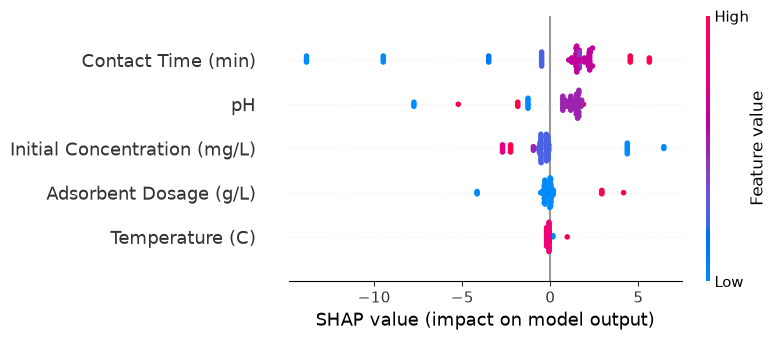

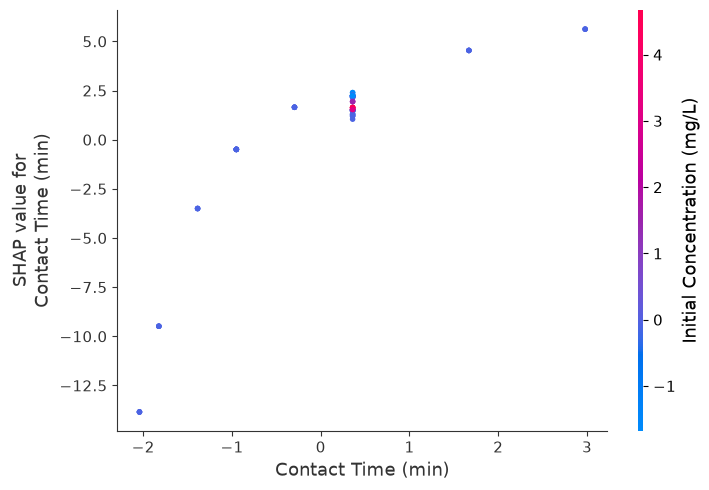

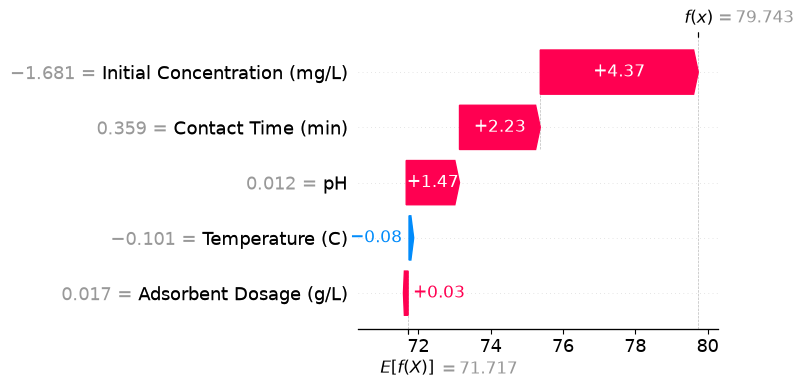

In [33]:
if hasattr(best_model, "feature_importances_"):
    display_names = [FEATURE_LABELS.get(f, f) for f in FEATURE_COLS]
    X_test_display = X_test_scaled.copy()
    X_test_display.columns = display_names

    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_scaled)

    # --- Summary plot ---
    shap.summary_plot(shap_values, X_test_display, show=False)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()

    # --- Dependence plot for the top feature ---
    top_feature = FEATURE_COLS[np.argmax(best_model.feature_importances_)]
    top_display_name = FEATURE_LABELS.get(top_feature, top_feature)
    shap.dependence_plot(top_display_name, shap_values, X_test_display, show=False)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / "shap_dependence_top_feature.png", dpi=150, bbox_inches="tight")
    plt.show()

    # --- Waterfall plot for a single example prediction ---
    base_value = explainer.expected_value
    if isinstance(base_value, (list, np.ndarray)):
        base_value = np.asarray(base_value).flatten()[0]

    expl = shap.Explanation(
        values=shap_values[0], base_values=base_value,
        data=X_test_display.iloc[0].values, feature_names=display_names,
    )
    shap.plots.waterfall(expl, show=False)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / "shap_waterfall_example.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Skipping SHAP TreeExplainer analysis: best model is not tree-based.")

## Done

All artifacts have been saved to `outputs/` and `models/` in the same
project structure as the standalone scripts:

- `outputs/test_set_metrics.csv`, `predicted_vs_actual.png`
- `outputs/feature_importance.csv/.png`
- `outputs/shap_summary.png`, `shap_dependence_top_feature.png` (from dependence_plot), waterfall plot
- `models/random_forest.joblib`, `svr.joblib`, `ann.joblib`, `scaler.joblib`

**When the real dataset arrives:** overwrite `data/raw/cv_removal_data.csv`
and re-run from Section 2 onward.
